In [1]:
import numpy as np
import matplotlib.pyplot as plt

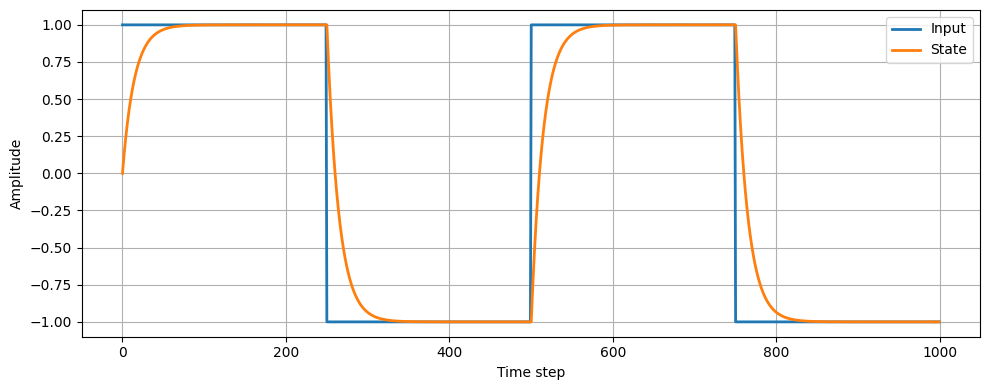

In [2]:
# system parameters
dt = 1.0 # time step width in s
Vs = 1.0 # Steady-state gain
tau = 15.0 # Time constant in s


a = (1-dt/tau);
b = (Vs*dt/tau);

# Generate input signal as multiple step functions towards +1 and -1 without a loop
N = 1000 # No. of samples
u = np.zeros(N)
u[0:250] = 1.0
u[250:500] = -1.0
u[500:750] = 1.0
u[750:1000] = -1.0

# simulate the true system
x = np.zeros(N)
for k in range(1, N):
    x[k] = a * x[k - 1] + b * u[k - 1]

# plot input and state
plt.figure(figsize=(10, 4))
plt.plot(u, label="Input", linewidth=2)
plt.plot(x, label="State", linewidth=2)
plt.xlabel("Time step")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#set up an OLS problem to identify the parameters of the model
Y = x[1:]
Z = np.column_stack([x[:-1], u[:-1]])
w = np.linalg.inv(Z.T @ Z) @ Z.T @ Y
a_hat, b_hat = w

Estimated parameters: a_hat = 0.9333, b_hat = 0.0667


array([[ 0.        ,  1.        ],
       [ 0.06666667,  1.        ],
       [ 0.12888889,  1.        ],
       ...,
       [-0.99999991, -1.        ],
       [-0.99999992, -1.        ],
       [-0.99999993, -1.        ]], shape=(999, 2))

In [7]:
# predict using identified model
x_hat = np.zeros(N)
for k in range(1, N):
    x_hat[k] = a_hat * x_hat[k - 1] + b_hat * u[k - 1]



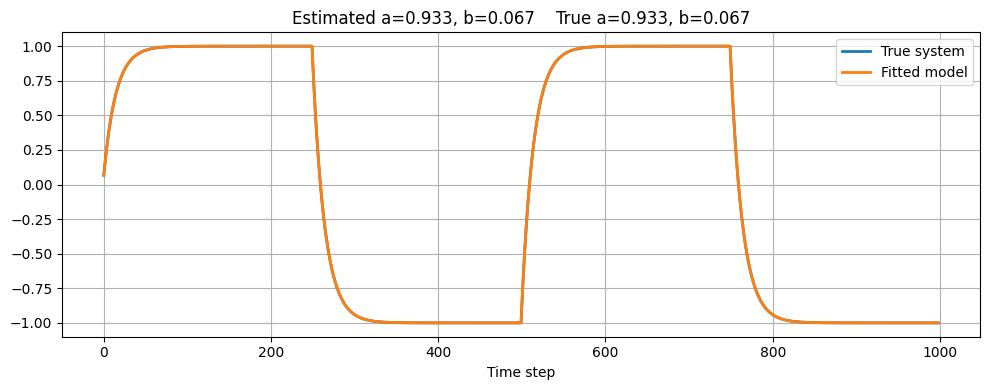

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(Y, label="True system", linewidth=2)
plt.plot(x_hat[1:], label="Fitted model", linewidth=2)
plt.xlabel("Time step")
plt.legend()
plt.grid(True)
plt.title(f"Estimated a={a_hat:.3f}, b={b_hat:.3f}    True a={a:.3f}, b={b:.3f}")
plt.tight_layout()
plt.show()

In [9]:
#redo the parameter identification with measurement noise on the states
sigma = 0.1 # standard deviation of measurement noise
x_noisy = x + sigma * np.random.randn(N) # add noise to the states

#set up an OLS problem to identify the parameters of the model
Y_noisy = x_noisy[1:]
Z_noisy = np.column_stack([x_noisy[:-1], u[:-1]])
w_noisy = np.linalg.inv(Z_noisy.T @ Z_noisy) @ Z_noisy.T @ Y_noisy
a_noisy, b_noisy = w_noisy

# Generate predicted output signal
x_hat_noisy = np.zeros(N)
for k in range(1, N):
    x_hat_noisy[k] = a_noisy * x_hat_noisy[k - 1] + b_noisy * u[k - 1]



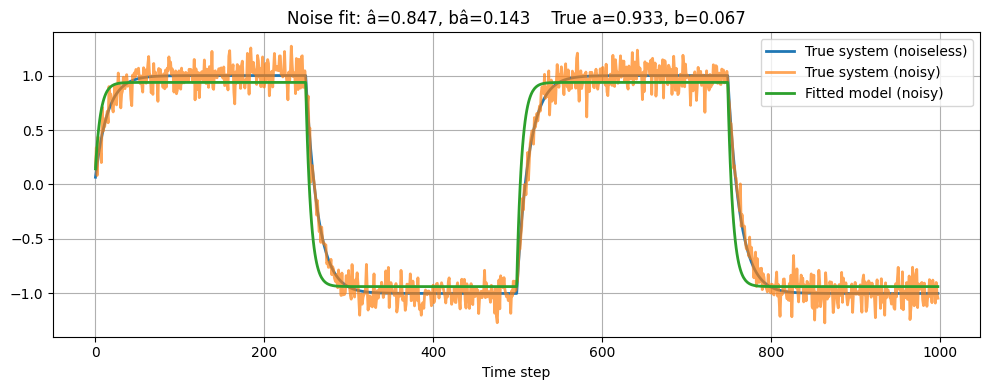

In [10]:
# plot the predicted model output vs. the ground truth data
plt.figure(figsize=(10, 4))
plt.plot(Y, label="True system (noiseless)", linewidth=2)
plt.plot(Y_noisy, label="True system (noisy)", linewidth=2, alpha=0.7)
plt.plot(x_hat_noisy[1:], label="Fitted model (noisy)", linewidth=2)
plt.xlabel("Time step")
plt.legend()
plt.grid(True)
plt.title(
    f"Noise fit: â={a_noisy:.3f}, bâ={b_noisy:.3f}    True a={a:.3f}, b={b:.3f}"
)
plt.tight_layout()
plt.show()